In [335]:
import numpy as np
import simulate_data as sim
from importlib import reload
reload(sim)
import pandas as pd
import matplotlib.pyplot as plt
import mfvb
reload(mfvb)
from mfvb import q_tobit

Censored low: 100  |  uncensored: 700  |  Censored high: 200


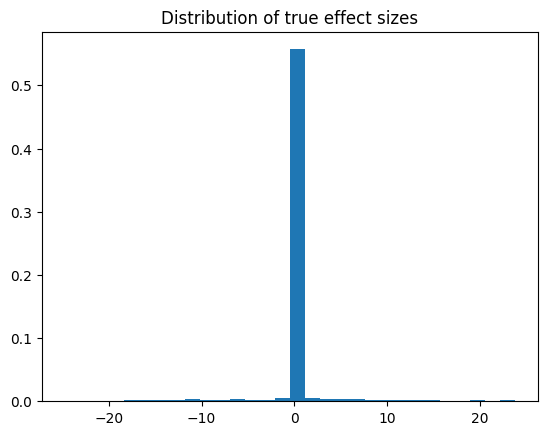

In [350]:
###simulate data
rng= np.random.default_rng(42)

n, d = 1_000, 2_000
l_perc, u_perc = 10, 80
r2 = 0.5
snr = r2/(1-r2)
perc_sig = 0.1

X = sim.X_corr_blocks(n, d, k = 5, corr =0.7, seed = 42, intercept = False)
beta_true = sim.beta_sparse(d, beta_scale, perc_sig, seed = 42)
y, l, u, sigma_y_true, snr= sim.y_tobit_2(X, l_perc, u_perc, beta_true, snr = snr, seed=42)

mask_l   = (y == l)
mask_u   = (y == u)
mask_mid = ~mask_l & ~mask_u

print(f"Censored low: {mask_l.sum()}  |  uncensored: {mask_mid.sum()}  |  Censored high: {mask_u.sum()}")

plt.hist(beta_true, bins =30, density = True)
plt.title("Distribution of true effect sizes")
plt.show()

In [353]:
model = q_tobit(
    X, y,
    tau2=100.0,     # wariancja priora na beta (slab)
    pi0=0.1,       # prior na prawdopodobieństwo włączenia zmiennej
    delta=0.01,    # kształt priora InvGamma na sigma^2
    eps=0.01,      # skala priora InvGamma na sigma^2
    seed=42        # dla powtarzalności
)


model.fit(n_iter=50) 

MFVI:   0%|          | 0/50 [00:00<?, ?it/s]

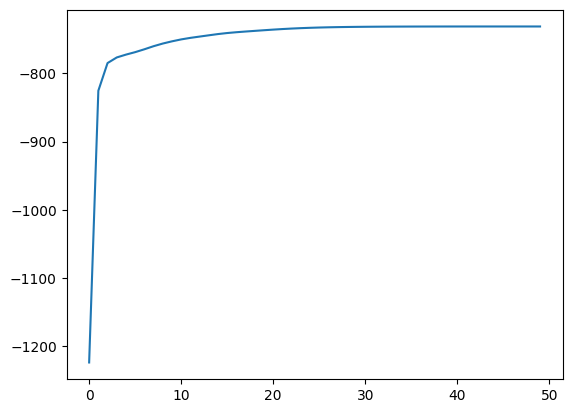

In [354]:
plt.plot(model.elbo_history)

In [355]:
sig_vi = model.rho >0.5
sig_true = beta_true !=0

TP = (sig_true & sig_vi).sum()
TN =( (~sig_true) & (~sig_vi)).sum()
FP = ((~sig_true) & sig_vi).sum()
FN = (sig_true & (~sig_vi)).sum()

precision   = TP / (TP + FP) if (TP + FP) > 0 else np.nan          # PPV
recall      = TP / (TP + FN) if (TP + FN) > 0 else np.nan          # sensitivity/power
specificity = TN / (TN + FP) if (TN + FP) > 0 else np.nan          # 1 - FPR
npv         = TN / (TN + FN) if (TN + FN) > 0 else np.nan
fdr         = FP / (TP + FP) if (TP + FP) > 0 else np.nan          # false discovery rate
fpr         = FP / (FP + TN) if (FP + TN) > 0 else np.nan
fnr         = FN / (FN + TP) if (FN + TP) > 0 else np.nan
accuracy    = (TP + TN) / n
f1          = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else np.nan

# Matthews Correlation Coefficient - dobra miara zbiorcza przy niezbalansowanych klasach
mcc_denom = np.sqrt((TP+FP)*(TP+FN)*(TN+FP)*(TN+FN))
mcc = (TP*TN - FP*FN) / mcc_denom if mcc_denom > 0 else np.nan

stats = pd.DataFrame({
    "Metryka": ["Precision (PPV)", "Recall (Power/Sensitivity)", "Specificity",
                "NPV", "FDR", "FPR", "FNR", "Accuracy", "F1-score", "MCC"],
    "Wartość": [precision, recall, specificity, npv, fdr, fpr, fnr, accuracy, f1, mcc]
})
stats["Wartość"] = stats["Wartość"].round(3)

confusion = pd.DataFrame(
    [[TP, FN], [FP, TN]],
    index=["Rzeczywisty: istotny", "Rzeczywisty: nieistotny"],
    columns=["Predykcja: istotny", "Predykcja: nieistotny"]
)

print(confusion)
print()
print(stats.to_string(index=False))

                         Predykcja: istotny  Predykcja: nieistotny
Rzeczywisty: istotny                     29                    180
Rzeczywisty: nieistotny                  14                   1777

                   Metryka  Wartość
           Precision (PPV)    0.674
Recall (Power/Sensitivity)    0.139
               Specificity    0.992
                       NPV    0.908
                       FDR    0.326
                       FPR    0.008
                       FNR    0.861
                  Accuracy    1.806
                  F1-score    0.230
                       MCC    0.276


In [356]:
import numpy as np
import pandas as pd

def block_confusion_stats(sig_true, sig_vi, k):
    """
    Statystyki na poziomie bloków skorelowanych zmiennych.
    Blok uznaje się za:
      - true-positive block: zawiera >=1 prawdziwy sygnał ORAZ >=1 wybraną zmienną
      - false-negative block: zawiera >=1 prawdziwy sygnał, ale ŻADNA zmienna nie została wybrana
      - false-positive block: nie zawiera sygnału, ale >=1 zmienna została wybrana
      - true-negative block: nie zawiera sygnału i żadna zmienna nie została wybrana
    """
    d = len(sig_true)
    assert d % k == 0, "d musi być podzielne przez k"
    n_blocks = d // k

    sig_true_b = sig_true.reshape(n_blocks, k)
    sig_vi_b   = sig_vi.reshape(n_blocks, k)

    block_has_true = sig_true_b.any(axis=1)   # (n_blocks,) - czy blok zawiera sygnał
    block_has_vi   = sig_vi_b.any(axis=1)     # (n_blocks,) - czy cokolwiek z bloku wybrano

    TP = (block_has_true & block_has_vi).sum()
    TN = ((~block_has_true) & (~block_has_vi)).sum()
    FP = ((~block_has_true) & block_has_vi).sum()
    FN = (block_has_true & (~block_has_vi)).sum()

    return TP, TN, FP, FN, n_blocks


def compute_stats(TP, TN, FP, FN):
    n = TP + TN + FP + FN
    precision   = TP / (TP + FP) if (TP + FP) > 0 else np.nan
    recall      = TP / (TP + FN) if (TP + FN) > 0 else np.nan
    specificity = TN / (TN + FP) if (TN + FP) > 0 else np.nan
    npv         = TN / (TN + FN) if (TN + FN) > 0 else np.nan
    fdr         = FP / (TP + FP) if (TP + FP) > 0 else np.nan
    fpr         = FP / (FP + TN) if (FP + TN) > 0 else np.nan
    fnr         = FN / (FN + TP) if (FN + TP) > 0 else np.nan
    accuracy    = (TP + TN) / n if n > 0 else np.nan
    f1          = 2*precision*recall/(precision+recall) if (precision+recall) > 0 else np.nan
    mcc_denom   = np.sqrt((TP+FP)*(TP+FN)*(TN+FP)*(TN+FN))
    mcc         = (TP*TN - FP*FN) / mcc_denom if mcc_denom > 0 else np.nan

    stats = pd.DataFrame({
        "Metryka": ["Precision (PPV)", "Recall (Power/Sensitivity)", "Specificity",
                    "NPV", "FDR", "FPR", "FNR", "Accuracy", "F1-score", "MCC"],
        "Wartość": [precision, recall, specificity, npv, fdr, fpr, fnr, accuracy, f1, mcc]
    })
    stats["Wartość"] = stats["Wartość"].round(3)

    confusion = pd.DataFrame(
        [[TP, FN], [FP, TN]],
        index=["Rzeczywisty: istotny", "Rzeczywisty: nieistotny"],
        columns=["Predykcja: istotny", "Predykcja: nieistotny"]
    )
    return confusion, stats


# --- użycie ---
k = 5  # rozmiar bloku - dopasuj do struktury korelacji w X
TP, TN, FP, FN, n_blocks = block_confusion_stats(sig_true, sig_vi, k)
confusion, stats = compute_stats(TP, TN, FP, FN)

print(f"Liczba bloków: {n_blocks} (rozmiar bloku k={k})")
print(confusion)
print()
print(stats.to_string(index=False))

Liczba bloków: 400 (rozmiar bloku k=5)
                         Predykcja: istotny  Predykcja: nieistotny
Rzeczywisty: istotny                     39                    133
Rzeczywisty: nieistotny                   4                    224

                   Metryka  Wartość
           Precision (PPV)    0.907
Recall (Power/Sensitivity)    0.227
               Specificity    0.982
                       NPV    0.627
                       FDR    0.093
                       FPR    0.018
                       FNR    0.773
                  Accuracy    0.658
                  F1-score    0.363
                       MCC    0.334
